# CCKW Analysis for 3D Fields (Omega, Ua, Va) and Precipitation

本脚本对垂直速度(omega/wa)、水平风场(ua, va)和降水(pr)进行Kelvin波滤波分析

**处理流程:**
1. 加载4D数据 (time, lev, lat, lon) - omega, ua, va
2. 加载2D降水数据 (time, lat, lon) 并转换单位为 mm/day
3. 对每个变量应用Kelvin波滤波
4. 计算标准差并可视化
5. 进行超前滞后回归分析 (lead-lag regression)
   - omega: 3D场回归
   - ua, va: 3D场回归到omega base point
   - pr: 2D场回归到omega base point

In [3]:
# Load packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmaps
from matplotlib.colors import LinearSegmentedColormap
import time
import sys
import gc
import pickle
from datetime import datetime
from scipy import signal
import dask.array as da

print("="*70)
print("✅ Packages loaded successfully")
print("="*70)

# Set up directories
OMEGA_DIR = "./omega_{}_layers"  # 使用格式化字符串
UA_DIR = "./ua_{}_layers"
VA_DIR = "./va_{}_layers"
fig_save_dir = "./figures/Cal_cckws_3d_fields/"
CACHE_DIR = "./cache/kelvin_wave_3d/"
CHECKPOINT_DIR = "./checkpoints/3d_fields/"

for d in [fig_save_dir, CACHE_DIR, CHECKPOINT_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"📁 Figure save directory: {fig_save_dir}")
print(f"📁 Cache directory: {CACHE_DIR}")
print(f"📁 Checkpoint directory: {CHECKPOINT_DIR}")
print("="*70)

✅ Packages loaded successfully
📁 Figure save directory: ./figures/Cal_cckws_3d_fields/
📁 Cache directory: ./cache/kelvin_wave_3d/
📁 Checkpoint directory: ./checkpoints/3d_fields/


In [4]:
# # 配置 SLURM 集群以处理大数据
# print("="*70)
# print("🖥️  Setting up SLURM Cluster for distributed computing")
# print("="*70)

# USE_SLURM = True  # 设置为 True 以使用 SLURM 集群

# if USE_SLURM:
#     from dask_jobqueue import SLURMCluster
#     from dask.distributed import Client
    
#     cluster = SLURMCluster(
#         name="kelvin_filter_3d",
#         queue="shared",
#         memory="100GB",  # 每个worker的内存
#         cores=64,        # 每个worker的核心数
#         interface="ib0",
#         account="mh1498",  # 您的账户
#         walltime="08:00:00",
#         local_directory="/work/mh1498/m301257",
#         log_directory="/work/mh1498/m301257/CCKW_work/logs",
#         scheduler_options={"dashboard_address": ":8788"},
#     )
    
#     client = Client(cluster)
#     cluster.scale(2)  # 启动2个worker，可根据需要调整
    
#     print(f"✅ SLURM Cluster initialized")
#     print(f"📊 Dashboard: {client.dashboard_link}")
#     print(f"🔗 Scheduler: {client.scheduler_info()['address']}")
#     print(f"👷 Workers: Scaling to 2")
#     print("="*70)
#     print("⏳ Waiting for workers to start...")
#     client.wait_for_workers(n_workers=1, timeout=300)  # 等待至少1个worker启动
#     print("✅ Workers ready!")
    
# else:
#     print("⚠️  Running in local mode (no SLURM)")
#     client = None

# print("="*70)

In [5]:
# 辅助函数

def save_checkpoint(data, step_name, exp_name, var_name):
    """保存检查点"""
    checkpoint_file = os.path.join(CHECKPOINT_DIR, f"{step_name}_{var_name}_{exp_name}.pkl")
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(data, f)
    print(f"  💾 Checkpoint saved: {checkpoint_file}")

def load_checkpoint(step_name, exp_name, var_name):
    """加载检查点"""
    checkpoint_file = os.path.join(CHECKPOINT_DIR, f"{step_name}_{var_name}_{exp_name}.pkl")
    if os.path.exists(checkpoint_file):
        with open(checkpoint_file, 'rb') as f:
            data = pickle.load(f)
        print(f"  ♻️ Checkpoint loaded: {checkpoint_file}")
        return data
    return None

def format_time(seconds):
    """格式化时间显示"""
    if seconds < 60:
        return f"{seconds:.1f}秒"
    elif seconds < 3600:
        return f"{seconds/60:.1f}分钟"
    else:
        return f"{seconds/3600:.1f}小时"

print("✅ 辅助函数定义完成")

✅ 辅助函数定义完成


In [6]:
# 创建colormap
def create_improved_colormap():
    """Create improved red-white-blue colormap"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()

In [7]:
# 导入WaveFilter类（优化用于大数据处理）
import numpy as np
from scipy import signal
import xarray as xr
import matplotlib.pyplot as plt
import dask.array as da

class WaveFilter:
    def __init__(self, ds=None, var=None, sel_dict=None, wave_name=None, units=None, spd=1, n_workers=4, use_distributed=False):
        self.sel_dict = sel_dict
        self.wave_name = wave_name
        self.n_workers = n_workers
        self.spd = spd
        self.data = None
        self.units = units
        self.filtered_data = None
        self.fftdata = None
        self.var = var
        self.use_distributed = use_distributed
        
        if isinstance(ds, str):
            # 使用更小的chunk以避免内存问题
            self.ds = xr.open_dataset(ds, chunks={'time': 365})
        elif isinstance(ds, (xr.Dataset, xr.DataArray)):
            self.ds = ds
        else:
            raise ValueError("`data` 必须是文件路径 (str) 或 `xarray.Dataset` / `xarray.DataArray`")
            
    def __repr__(self):
        lat_sel = self.sel_dict.get('lat') if self.sel_dict and 'lat' in self.sel_dict else None
        time_sel = self.sel_dict.get('time') if self.sel_dict and 'time' in self.sel_dict else None
        lines = [
            "📡 WaveFilter Summary:",
            f"  • Wave Type     : {self.wave_name or 'N/A'}",
            f"  • Variable      : {self.var or 'N/A'}",
            f"  • Time Range    : {time_sel or 'N/A'}",
            f"  • Latitude Range: {lat_sel or 'N/A'}",
            f"  • Units         : {self.units or 'N/A'}",
            f"  • Workers       : {self.n_workers}",
            f"  • Sampling/day  : {self.spd}",
            f"  • Distributed   : {self.use_distributed}",
        ]
        if self.data is not None:
            lines.append(f"  • Data Shape    : {self.data.shape}")
            lines.append(f"  • Data Dims     : {tuple(self.data.dims)}")
        else:
            lines.append("  • Data          : Not loaded")
        return "\n".join(lines)
    
    def print_diagnostic_info(self, variable, name):
        """打印变量的诊断信息"""
        try:
            print(f"\n=================={name} Information ====================")
            print(f"Type: {type(variable)}")
            print(f"Shape: {variable.shape}")
            if isinstance(variable, (da.Array, np.ndarray, xr.DataArray)):
                print(f"Data type: {variable.dtype}")
            if isinstance(variable, da.Array):
                print(f"Chunks: {variable.chunks}")
            print("=============================================================")
        except Exception as e:
            print(f"Error printing info for {name}: {e}")
            
    def load_data(self):
        """Load and preprocess data with optimized chunking."""
        if isinstance(self.ds, xr.Dataset):
            self.data = self.ds[self.var].sortby('lat')
        elif isinstance(self.ds, xr.DataArray):
            self.data = self.ds.sortby('lat')
        
        sel_kwargs = {}
        if self.sel_dict:
            sel_kwargs.update(self.sel_dict)
        
        if sel_kwargs:
            self.data = self.data.sel(**sel_kwargs)
        
        # 转置维度以确保正确的顺序
        if len(self.data.dims) == 3:
            # 3D: (time, lat, lon)
            if 'time' in self.data.dims and 'lat' in self.data.dims and 'lon' in self.data.dims:
                self.data = self.data.transpose('time', 'lat', 'lon')
            # 关键修复：FFT需要时间和经度维度只有一个chunk
            self.data = self.data.chunk({'time': -1, 'lat': 'auto', 'lon': -1})
        elif len(self.data.dims) == 4:
            # 4D: 转置为 (time, level, lat, lon)
            if 'level' in self.data.dims:
                self.data = self.data.transpose('time', 'level', 'lat', 'lon')
            elif 'lev' in self.data.dims:
                self.data = self.data.transpose('time', 'lev', 'lat', 'lon')
            elif 'plev' in self.data.dims:
                self.data = self.data.transpose('time', 'plev', 'lat', 'lon')
            # 关键修复：FFT需要时间和经度维度只有一个chunk
            self.data = self.data.chunk({'time': -1, 'lat': 'auto', 'lon': -1})
        
        self.print_diagnostic_info(self.data, 'Loaded Data')
        
    def detrend_data(self):
        """Detrend the data using dask for parallel processing."""
        shape = self.data.shape
        ntim = shape[0]
        spd = self.spd
        
        # 确保时间维度完全加载到内存
        data_rechunked = self.data.data.rechunk({0: -1})
        
        if ntim > 365*spd/3:
            rf = da.fft.rfft(data_rechunked, axis=0)
            freq = da.fft.rfftfreq(ntim * spd, d=1. / float(spd))
            # 过滤低频成分
            rf[(freq <= 3. / 365) & (freq >= 1. / 365)] = 0.0
            datain = da.fft.irfft(rf, axis=0, n=ntim)
        else:
            datain = data_rechunked
        
        # 沿时间轴去趋势
        self.detrend = da.apply_along_axis(signal.detrend, 0, datain)
        
        # 应用窗口函数
        window = signal.windows.tukey(ntim, 0.05, True)
        
        # 对不同维度应用窗口
        if len(shape) == 3:
            self.detrend = self.detrend * window[:, np.newaxis, np.newaxis]
        elif len(shape) == 4:
            self.detrend = self.detrend * window[:, np.newaxis, np.newaxis, np.newaxis]
        
    def fft_transform(self):
        """Perform 2D FFT on the detrended data using dask."""
        lon_axis = -1  # 最后一个维度是lon
        nlon = self.data.shape[lon_axis]
        
        self.wavenumber = -da.fft.fftfreq(nlon) * nlon
        self.frequency = da.fft.fftfreq(self.data.shape[0], d=1. / float(1))
        self.knum_ori, self.freq_ori = da.meshgrid(self.wavenumber, self.frequency)
        self.knum = self.knum_ori.copy()
        self.knum = da.where(self.freq_ori < 0, -self.knum_ori, self.knum_ori)
        self.freq = da.abs(self.freq_ori)
    
    def apply_filter(self):
        """Apply filter based on wave type."""
        if self.wave_name.lower() == "kelvin":
            self.tMin, self.tMax = 3, 20
            self.kmin, self.kmax = 2, 14
            self.hmin, self.hmax = 8, 90
        elif self.wave_name.lower() == "er":
            self.tMin, self.tMax = 9, 72
            self.kmin, self.kmax = -10, -1
            self.hmin, self.hmax = 8, 90
        
        self.fmin, self.fmax = 1 / self.tMax, 1 / self.tMin
        self.mask = da.zeros((self.data.shape[0], self.data.shape[-1]), dtype=bool)
        
        if self.kmin is not None:
            self.mask = self.mask | (self.knum < self.kmin)
        if self.kmax is not None:
            self.mask = self.mask | (self.kmax < self.knum)
        if self.fmin is not None:
            self.mask = self.mask | (self.freq < self.fmin)
        if self.fmax is not None:
            self.mask = self.mask | (self.fmax < self.freq)
        
        if self.wave_name.lower() in ['kelvin', 'er']:
            self.apply_wave_filter(self.wave_name)
        
        # 对3D或4D数据进行FFT
        if len(self.data.shape) == 3:
            self.fftdata = da.fft.fft2(self.detrend, axes=(0, 2))
            self.mask = da.repeat(self.mask[:, np.newaxis, :], self.data.shape[1], axis=1)
        elif len(self.data.shape) == 4:
            # 4D: (time, level, lat, lon) - FFT在time和lon维度
            self.fftdata = da.fft.fft2(self.detrend, axes=(0, 3))
            # 扩展mask到(time, level, lat, lon)
            nlev = self.data.shape[1]
            nlat = self.data.shape[2]
            self.mask = self.mask[:, np.newaxis, np.newaxis, :]
            self.mask = da.broadcast_to(self.mask, (self.data.shape[0], nlev, nlat, self.data.shape[3]))
        
        self.fftdata = da.where(self.mask, 0.0, self.fftdata)
    
    def apply_wave_filter(self, wave_name):
        """Apply Kelvin or ER wave filter."""
        g = 9.8
        beta = 2.28e-11
        a = 6.37e6
        n = 1
        
        if self.wave_name.lower() == "kelvin":
            if self.hmin is not None:
                c = da.sqrt(g * self.hmin)
                omega = 2. * np.pi * self.freq / 24. / 3600. / da.sqrt(beta * c)
                k = self.knum / a * da.sqrt(c / beta)
                self.mask = self.mask | (omega - k < 0)
            if self.hmax is not None:
                c = da.sqrt(g * self.hmax)
                omega = 2. * np.pi * self.freq / 24. / 3600. / da.sqrt(beta * c)
                k = self.knum / a * da.sqrt(c / beta)
                self.mask = self.mask | (omega - k > 0)
        
        if self.wave_name.lower() == "er":
            if self.hmin is not None:
                c = da.sqrt(g * self.hmin)
                omega = 2. * np.pi * self.freq / 24. / 3600. / da.sqrt(beta * c)
                k = self.knum / a * da.sqrt(c / beta)
                self.mask = self.mask | (omega * (k ** 2 + (2 * n + 1)) + k < 0)
            if self.hmax is not None:
                c = da.sqrt(g * self.hmax)
                omega = 2. * np.pi * self.freq / 24. / 3600. / da.sqrt(beta * c)
                k = self.knum / a * da.sqrt(c / beta)
                self.mask = self.mask | (omega * (k ** 2 + (2 * n + 1)) + k > 0)
    
    def inverse_fft(self):
        """Perform inverse FFT to get filtered data."""
        if len(self.data.shape) == 3:
            self.filtered_data = da.fft.ifft2(self.fftdata, axes=(0, 2)).real
        elif len(self.data.shape) == 4:
            self.filtered_data = da.fft.ifft2(self.fftdata, axes=(0, 3)).real
    
    def create_output(self):
        """Create xarray DataArray for filtered data with distributed computing."""
        coords = {dim: self.data[dim] for dim in self.data.dims}
        
        # 如果使用分布式计算，使用persist()而不是立即compute()
        if self.use_distributed:
            print("      🔄 Persisting data to distributed memory...")
            filtered_computed = self.filtered_data.persist()
        else:
            print("      🔄 Computing filtered data...")
            filtered_computed = self.filtered_data.compute()
        
        self.wave_data = xr.DataArray(
            filtered_computed,
            coords=coords,
            dims=list(self.data.dims)
        )
        
        self.wave_data.attrs.update({
            'long_name': self.wave_name,
            'min_equiv_depth': self.hmin,
            'max_equiv_depth': self.hmax,
            'min_wavenumber': self.kmin,
            'max_wavenumber': self.kmax,
            'min_period': self.tMin,
            'max_period': self.tMax,
            'min_frequency': self.fmin,
            'max_frequency': self.fmax,
            'units': self.units,
        })
        
        # 如果是分布式，最后才compute
        if self.use_distributed:
            print("      🔄 Final computation...")
            return self.wave_data.compute()
        else:
            return self.wave_data

print("✅ WaveFilter类加载完成（已优化支持大数据和分布式计算）")

✅ WaveFilter类加载完成（已优化支持大数据和分布式计算）


In [8]:
# Step 1: 加载3D数据 (omega, ua, va)
print("="*70)
print("📊 Loading 3D atmospheric data")
print("="*70)

# 定义实验和目录映射
exp_dir_map = {
    'CNTL': 'cntl',
    'P4K': 'p4k',
    '4CO2': '4co2'
}

# 数据存储字典
omega_data = {}
ua_data = {}
va_data = {}

for exp, dir_name in exp_dir_map.items():
    print(f"\n{'='*60}")
    print(f"📍 Loading {exp} data")
    print(f"{'='*60}")
    
    # 加载垂直速度 (omega/wa)
    omega_file = f"./omega_{dir_name}_layers/wa_all_levels.nc"
    try:
        omega_ds = xr.open_dataset(omega_file)
        # 通常变量名是'wa'或'omega'
        if 'wa' in omega_ds:
            omega_data[exp] = omega_ds['wa']
        elif 'omega' in omega_ds:
            omega_data[exp] = omega_ds['omega']
        else:
            # 如果不确定变量名，取第一个数据变量
            omega_data[exp] = omega_ds[list(omega_ds.data_vars)[0]]
        print(f"  ✅ Omega: {omega_data[exp].shape} {omega_data[exp].dims}")
    except Exception as e:
        print(f"  ❌ Omega: Failed - {str(e)}")
    
    # 加载纬向风 (ua)
    ua_file = f"./ua_{dir_name}_layers/ua_all_levels.nc"
    try:
        ua_ds = xr.open_dataset(ua_file)
        ua_data[exp] = ua_ds['ua'] if 'ua' in ua_ds else ua_ds[list(ua_ds.data_vars)[0]]
        print(f"  ✅ Ua: {ua_data[exp].shape} {ua_data[exp].dims}")
    except Exception as e:
        print(f"  ❌ Ua: Failed - {str(e)}")
    
    # 加载经向风 (va)
    va_file = f"./va_{dir_name}_layers/va_all_levels.nc"
    try:
        va_ds = xr.open_dataset(va_file)
        va_data[exp] = va_ds['va'] if 'va' in va_ds else va_ds[list(va_ds.data_vars)[0]]
        print(f"  ✅ Va: {va_data[exp].shape} {va_data[exp].dims}")
    except Exception as e:
        print(f"  ❌ Va: Failed - {str(e)}")

print("\n" + "="*70)
print("✅ All 3D data loaded successfully")
print("="*70)

📊 Loading 3D atmospheric data

📍 Loading CNTL data
  ✅ Omega: (22, 5114, 15, 180) ('level', 'time', 'lat', 'lon')
  ✅ Ua: (22, 5114, 15, 180) ('level', 'time', 'lat', 'lon')
  ✅ Va: (22, 5114, 15, 180) ('level', 'time', 'lat', 'lon')

📍 Loading P4K data
  ✅ Omega: (22, 5114, 15, 180) ('level', 'time', 'lat', 'lon')
  ✅ Ua: (22, 5114, 15, 180) ('level', 'time', 'lat', 'lon')
  ✅ Va: (22, 5114, 15, 180) ('level', 'time', 'lat', 'lon')

📍 Loading 4CO2 data
  ✅ Omega: (22, 5114, 15, 180) ('level', 'time', 'lat', 'lon')
  ✅ Ua: (22, 5114, 15, 180) ('level', 'time', 'lat', 'lon')
  ✅ Va: (22, 5114, 15, 180) ('level', 'time', 'lat', 'lon')

✅ All 3D data loaded successfully


In [9]:
# Step 2: 对每个变量和实验应用Kelvin波滤波（使用分布式计算）
print("="*70)
print("🌊 Applying Kelvin wave filter to 3D fields")
if USE_SLURM:
    print("🖥️  Using SLURM distributed computing")
else:
    print("⚠️  Using local computing (may be slow for large data)")
print("="*70)

sel_dict = {
    'time': slice('1980-01-01', '1993-12-31'),
    'lat': slice(-15, 15)
}
wave_name = 'kelvin'

# 存储滤波后的数据
kelvin_omega = {}
kelvin_ua = {}
kelvin_va = {}

variables = [
    ('omega', omega_data, kelvin_omega, 'Pa/s'),
    ('ua', ua_data, kelvin_ua, 'm/s'),
    ('va', va_data, kelvin_va, 'm/s')
]

total_start_time = time.time()

for var_name, input_data, output_dict, units in variables:
    print(f"\n{'='*70}")
    print(f"🔄 Processing {var_name.upper()}")
    print(f"{'='*70}")
    
    for i, exp in enumerate(['CNTL', 'P4K', '4CO2'], 1):
        print(f"\n  📍 {exp} - {var_name.upper()} ({i}/3)")
        
        # 检查缓存
        cache_file = os.path.join(CACHE_DIR, f'kelvin_{var_name}_{exp.lower()}.nc')
        
        if os.path.exists(cache_file):
            print(f"    ♻️ Loading from cache...")
            output_dict[exp] = xr.open_dataarray(cache_file)
            print(f"    ✅ Loaded! Shape: {output_dict[exp].shape}")
            continue
        
        # 如果没有缓存，进行计算
        exp_start_time = time.time()
        
        try:
            wave_filter = WaveFilter(
                ds=input_data[exp],
                sel_dict=sel_dict,
                wave_name=wave_name,
                units=units,
                spd=1,
                n_workers=4,
                use_distributed=USE_SLURM  # 使用分布式计算
            )
            
            print(f"    ⏳ Step 1/5: Loading data...")
            wave_filter.load_data()
            
            print(f"    ⏳ Step 2/5: Detrending...")
            wave_filter.detrend_data()
            
            print(f"    ⏳ Step 3/5: FFT transform...")
            wave_filter.fft_transform()
            
            print(f"    ⏳ Step 4/5: Applying filter...")
            wave_filter.apply_filter()
            
            print(f"    ⏳ Step 5/5: Inverse FFT and computing...")
            wave_filter.inverse_fft()
            filtered_data = wave_filter.create_output()
            
            # 保存到缓存
            print(f"    💾 Saving to cache...")
            # 使用压缩以节省磁盘空间
            encoding = {filtered_data.name or 'data': {'zlib': True, 'complevel': 4}}
            filtered_data.to_netcdf(cache_file, encoding=encoding)
            
            output_dict[exp] = filtered_data
            
            exp_elapsed = time.time() - exp_start_time
            print(f"    ✅ Completed in {format_time(exp_elapsed)}")
            print(f"       Shape: {filtered_data.shape}")
            print(f"       Memory: {filtered_data.nbytes / 1e9:.2f} GB")
            
            # 清理内存
            del wave_filter, filtered_data
            gc.collect()
            
            # 如果使用SLURM，显示集群状态
            if USE_SLURM and client is not None:
                try:
                    workers = client.scheduler_info()['workers']
                    total_mem = sum([w.get('memory_limit', 0) for w in workers.values()]) / 1e9
                    print(f"    📊 Cluster: {len(workers)} workers, {total_mem:.1f} GB total memory")
                except:
                    pass
            
        except Exception as e:
            print(f"    ❌ Error: {str(e)}")
            import traceback
            traceback.print_exc()

total_elapsed = time.time() - total_start_time
print("\n" + "="*70)
print(f"✅ All 3D fields filtered in {format_time(total_elapsed)}")
print("="*70)

# 如果使用SLURM，显示最终统计
if USE_SLURM and client is not None:
    print(f"\n📊 Cluster Statistics:")
    try:
        workers_info = client.scheduler_info()['workers']
        print(f"   Total workers: {len(workers_info)}")
        total_memory = sum([w.get('memory_limit', 0) for w in workers_info.values()]) / 1e9
        print(f"   Total memory: {total_memory:.1f} GB")
    except Exception as e:
        print(f"   (Statistics unavailable: {e})")
    print("="*70)

🌊 Applying Kelvin wave filter to 3D fields
🖥️  Using SLURM distributed computing

🔄 Processing OMEGA

  📍 CNTL - OMEGA (1/3)
    ♻️ Loading from cache...
    ✅ Loaded! Shape: (5114, 22, 15, 180)

  📍 P4K - OMEGA (2/3)
    ♻️ Loading from cache...
    ✅ Loaded! Shape: (5114, 22, 15, 180)

  📍 4CO2 - OMEGA (3/3)
    ♻️ Loading from cache...
    ✅ Loaded! Shape: (5114, 22, 15, 180)

🔄 Processing UA

  📍 CNTL - UA (1/3)
    ♻️ Loading from cache...
    ✅ Loaded! Shape: (5114, 22, 15, 180)

  📍 P4K - UA (2/3)
    ♻️ Loading from cache...
    ✅ Loaded! Shape: (5114, 22, 15, 180)

  📍 4CO2 - UA (3/3)
    ♻️ Loading from cache...
    ✅ Loaded! Shape: (5114, 22, 15, 180)

🔄 Processing VA

  📍 CNTL - VA (1/3)
    ♻️ Loading from cache...
    ✅ Loaded! Shape: (5114, 22, 15, 180)

  📍 P4K - VA (2/3)
    ♻️ Loading from cache...
    ✅ Loaded! Shape: (5114, 22, 15, 180)

  📍 4CO2 - VA (3/3)
    ♻️ Loading from cache...
    ✅ Loaded! Shape: (5114, 22, 15, 180)

✅ All 3D fields filtered in 0.4秒

📊 Clu

# 垂直结构演变分析 (Vertical Evolution Analysis)

本节将对滤波后的wa数据进行合成分析，绘制类似于参考图的演变曲线。

**分析步骤:**
1. 检查缓存数据是否存在
2. 计算每个垂直层的时间平均和标准差
3. 进行相位合成分析（phase composite）
4. 绘制垂直剖面的演变曲线

In [10]:
# Step 3: 加载或检查缓存的滤波数据
print("="*70)
print("📦 Loading Kelvin-filtered data from cache")
print("="*70)

# 检查缓存文件是否存在
def check_cached_data(exp_list=['CNTL', 'P4K', '4CO2'], var_name='omega'):
    """检查缓存数据是否存在"""
    cache_status = {}
    for exp in exp_list:
        cache_file = os.path.join(CACHE_DIR, f'kelvin_{var_name}_{exp.lower()}.nc')
        cache_status[exp] = os.path.exists(cache_file)
        status_icon = "✅" if cache_status[exp] else "❌"
        print(f"  {status_icon} {exp}: {cache_file}")
    return cache_status

# 检查omega数据
print("\n🌀 Checking Omega/Wa data:")
omega_cache_status = check_cached_data(var_name='omega')

# 检查ua数据
print("\n➡️  Checking Ua data:")
ua_cache_status = check_cached_data(var_name='ua')

# 检查va数据  
print("\n⬆️  Checking Va data:")
va_cache_status = check_cached_data(var_name='va')

print("\n" + "="*70)
all_cached = all(omega_cache_status.values())
if all_cached:
    print("✅ All omega data is cached - can proceed without restarting cluster")
else:
    print("⚠️  Some data is missing - you may need to run the filtering step first")
print("="*70)

📦 Loading Kelvin-filtered data from cache

🌀 Checking Omega/Wa data:
  ✅ CNTL: ./cache/kelvin_wave_3d/kelvin_omega_cntl.nc
  ✅ P4K: ./cache/kelvin_wave_3d/kelvin_omega_p4k.nc
  ✅ 4CO2: ./cache/kelvin_wave_3d/kelvin_omega_4co2.nc

➡️  Checking Ua data:
  ✅ CNTL: ./cache/kelvin_wave_3d/kelvin_ua_cntl.nc
  ✅ P4K: ./cache/kelvin_wave_3d/kelvin_ua_p4k.nc
  ✅ 4CO2: ./cache/kelvin_wave_3d/kelvin_ua_4co2.nc

⬆️  Checking Va data:
  ✅ CNTL: ./cache/kelvin_wave_3d/kelvin_va_cntl.nc
  ✅ P4K: ./cache/kelvin_wave_3d/kelvin_va_p4k.nc
  ✅ 4CO2: ./cache/kelvin_wave_3d/kelvin_va_4co2.nc

✅ All omega data is cached - can proceed without restarting cluster


In [11]:
# Step 4: 加载缓存的滤波数据
print("="*70)
print("📂 Loading filtered data for composite analysis")
print("="*70)

# 只加载omega数据进行垂直结构分析
kelvin_omega_loaded = {}

for exp in ['CNTL', 'P4K', '4CO2']:
    cache_file = os.path.join(CACHE_DIR, f'kelvin_omega_{exp.lower()}.nc')
    
    if os.path.exists(cache_file):
        print(f"\n  📍 Loading {exp}...")
        try:
            kelvin_omega_loaded[exp] = xr.open_dataarray(cache_file)
            print(f"    ✅ Loaded successfully")
            print(f"       Shape: {kelvin_omega_loaded[exp].shape}")
            print(f"       Dims: {kelvin_omega_loaded[exp].dims}")
            if 'lev' in kelvin_omega_loaded[exp].dims:
                print(f"       Levels: {len(kelvin_omega_loaded[exp].lev)} layers")
        except Exception as e:
            print(f"    ❌ Error loading: {str(e)}")
    else:
        print(f"\n  ⚠️  {exp}: Cache file not found!")
        print(f"      Please run the filtering step (Step 2) first")

print("\n" + "="*70)
if len(kelvin_omega_loaded) > 0:
    print(f"✅ Loaded {len(kelvin_omega_loaded)} experiments successfully")
else:
    print("❌ No data loaded - cannot proceed with composite analysis")
print("="*70)

📂 Loading filtered data for composite analysis

  📍 Loading CNTL...
    ✅ Loaded successfully
       Shape: (5114, 22, 15, 180)
       Dims: ('time', 'level', 'lat', 'lon')

  📍 Loading P4K...
    ✅ Loaded successfully
       Shape: (5114, 22, 15, 180)
       Dims: ('time', 'level', 'lat', 'lon')

  📍 Loading 4CO2...
    ✅ Loaded successfully
       Shape: (5114, 22, 15, 180)
       Dims: ('time', 'level', 'lat', 'lon')

✅ Loaded 3 experiments successfully


# 降水数据滤波 (Precipitation Filtering)

对降水数据进行Kelvin波滤波，注意降水是2维场 (time, lat, lon)，需要先转换单位为 mm/day

In [12]:
# Step 4a: 加载原始降水数据（未滤波）
print("="*70)
print("🌧️  Loading raw precipitation data")
print("="*70)

# 原始降水数据路径（插值到2度的数据）
pr_raw_files = {
    'CNTL': '/work/mh1498/m301257/processed_data/pr_cntl_2deg_interp.nc',
    'P4K': '/work/mh1498/m301257/processed_data/pr_4k_2deg_interp.nc',
    '4CO2': '/work/mh1498/m301257/processed_data/pr_4co2_2deg_interp.nc'
}

# 存储原始降水数据
pr_raw_data = {}

for exp, file_path in pr_raw_files.items():
    print(f"\n  📍 Loading {exp}...")
    
    try:
        # 加载数据
        pr_ds = xr.open_dataset(file_path)
        
        # 获取降水变量（通常是'pr'）
        if 'pr' in pr_ds:
            pr_data = pr_ds['pr']
        else:
            pr_data = pr_ds[list(pr_ds.data_vars)[0]]
        
        # 转换单位：kg m-2 s-1 to mm/day
        # 1 kg m-2 s-1 = 86400 mm/day
        pr_data_mmday = pr_data * 86400
        pr_data_mmday.attrs['units'] = 'mm/day'
        
        pr_raw_data[exp] = pr_data_mmday
        
        print(f"    ✅ Loaded successfully")
        print(f"       Shape: {pr_raw_data[exp].shape}")
        print(f"       Dims: {pr_raw_data[exp].dims}")
        print(f"       Units: mm/day")
        print(f"       Value range: [{float(pr_raw_data[exp].min().values):.2f}, {float(pr_raw_data[exp].max().values):.2f}]")
        
    except Exception as e:
        print(f"    ❌ Error: {str(e)}")
        import traceback
        traceback.print_exc()

print("\n" + "="*70)
print(f"✅ Loaded {len(pr_raw_data)} precipitation datasets")
print("="*70)

🌧️  Loading raw precipitation data

  📍 Loading CNTL...
    ✅ Loaded successfully
       Shape: (5114, 15, 180)
       Dims: ('time', 'lat', 'lon')
       Units: mm/day
       Value range: [-0.00, 605.05]

  📍 Loading P4K...
    ✅ Loaded successfully
       Shape: (5114, 15, 180)
       Dims: ('time', 'lat', 'lon')
       Units: mm/day
       Value range: [-0.00, 1065.91]

  📍 Loading 4CO2...
    ✅ Loaded successfully
       Shape: (5114, 15, 180)
       Dims: ('time', 'lat', 'lon')
       Units: mm/day
       Value range: [-0.00, 1086.20]

✅ Loaded 3 precipitation datasets


In [13]:
# Step 4b: 对降水数据应用Kelvin波滤波
print("="*70)
print("🌧️  Applying Kelvin wave filter to precipitation (2D field)")
if USE_SLURM:
    print("🖥️  Using SLURM distributed computing")
else:
    print("⚠️  Using local computing")
print("="*70)

sel_dict_pr = {
    'time': slice('1980-01-01', '1993-12-31'),
    'lat': slice(-15, 15)
}
wave_name = 'kelvin'

# 存储滤波后的降水数据
kelvin_pr = {}

total_start_time = time.time()

for i, exp in enumerate(['CNTL', 'P4K', '4CO2'], 1):
    print(f"\n  📍 {exp} - Precipitation ({i}/3)")
    
    # 检查缓存
    cache_file = os.path.join(CACHE_DIR, f'kelvin_pr_{exp.lower()}.nc')
    
    if os.path.exists(cache_file):
        print(f"    ♻️ Loading from cache...")
        kelvin_pr[exp] = xr.open_dataarray(cache_file)
        print(f"    ✅ Loaded! Shape: {kelvin_pr[exp].shape}")
        continue
    
    # 如果没有缓存，进行计算
    exp_start_time = time.time()
    
    try:
        wave_filter = WaveFilter(
            ds=pr_raw_data[exp],
            sel_dict=sel_dict_pr,
            wave_name=wave_name,
            units='mm/day',
            spd=1,
            n_workers=4,
            use_distributed=USE_SLURM
        )
        
        print(f"    ⏳ Step 1/5: Loading data...")
        wave_filter.load_data()
        
        print(f"    ⏳ Step 2/5: Detrending...")
        wave_filter.detrend_data()
        
        print(f"    ⏳ Step 3/5: FFT transform...")
        wave_filter.fft_transform()
        
        print(f"    ⏳ Step 4/5: Applying filter...")
        wave_filter.apply_filter()
        
        print(f"    ⏳ Step 5/5: Inverse FFT and computing...")
        wave_filter.inverse_fft()
        filtered_data = wave_filter.create_output()
        
        # 保存到缓存
        print(f"    💾 Saving to cache...")
        encoding = {filtered_data.name or 'data': {'zlib': True, 'complevel': 4}}
        filtered_data.to_netcdf(cache_file, encoding=encoding)
        
        kelvin_pr[exp] = filtered_data
        
        exp_elapsed = time.time() - exp_start_time
        print(f"    ✅ Completed in {format_time(exp_elapsed)}")
        print(f"       Shape: {filtered_data.shape}")
        print(f"       Memory: {filtered_data.nbytes / 1e9:.2f} GB")
        
        # 清理内存
        del wave_filter, filtered_data
        gc.collect()
        
    except Exception as e:
        print(f"    ❌ Error: {str(e)}")
        import traceback
        traceback.print_exc()

total_elapsed = time.time() - total_start_time
print("\n" + "="*70)
print(f"✅ Precipitation filtering completed in {format_time(total_elapsed)}")
print("="*70)

🌧️  Applying Kelvin wave filter to precipitation (2D field)
🖥️  Using SLURM distributed computing

  📍 CNTL - Precipitation (1/3)
    ♻️ Loading from cache...
    ✅ Loaded! Shape: (5114, 15, 180)

  📍 P4K - Precipitation (2/3)
    ♻️ Loading from cache...
    ✅ Loaded! Shape: (5114, 15, 180)

  📍 4CO2 - Precipitation (3/3)
    ♻️ Loading from cache...
    ✅ Loaded! Shape: (5114, 15, 180)

✅ Precipitation filtering completed in 0.1秒


In [14]:
# Step 4c: 加载所有滤波后的数据（omega, ua, va, pr）
print("="*70)
print("📂 Loading all filtered data for composite analysis")
print("="*70)

# 加载滤波后的u, v, pr数据
kelvin_ua_loaded = {}
kelvin_va_loaded = {}
kelvin_pr_loaded = {}

variables_to_load = [
    ('ua', kelvin_ua_loaded, 'Zonal Wind (U)'),
    ('va', kelvin_va_loaded, 'Meridional Wind (V)'),
    ('pr', kelvin_pr_loaded, 'Precipitation')
]

for var_name, var_dict, var_label in variables_to_load:
    print(f"\n{'='*60}")
    print(f"  📍 Loading {var_label}")
    print(f"{'='*60}")
    
    for exp in ['CNTL', 'P4K', '4CO2']:
        cache_file = os.path.join(CACHE_DIR, f'kelvin_{var_name}_{exp.lower()}.nc')
        
        if os.path.exists(cache_file):
            print(f"\n    📍 Loading {exp}...")
            try:
                var_dict[exp] = xr.open_dataarray(cache_file)
                print(f"      ✅ Loaded successfully")
                print(f"         Shape: {var_dict[exp].shape}")
                print(f"         Dims: {var_dict[exp].dims}")
                if 'lev' in var_dict[exp].dims:
                    print(f"         Levels: {len(var_dict[exp].lev)} layers")
            except Exception as e:
                print(f"      ❌ Error loading: {str(e)}")
        else:
            print(f"\n    ⚠️  {exp}: Cache file not found!")
            print(f"        Expected: {cache_file}")

print("\n" + "="*70)
loaded_vars = []
if len(kelvin_omega_loaded) > 0:
    loaded_vars.append('omega')
if len(kelvin_ua_loaded) > 0:
    loaded_vars.append('ua')
if len(kelvin_va_loaded) > 0:
    loaded_vars.append('va')
if len(kelvin_pr_loaded) > 0:
    loaded_vars.append('pr')

print(f"✅ Loaded variables: {', '.join(loaded_vars)}")
print(f"   Ready for composite analysis!")
print("="*70)

📂 Loading all filtered data for composite analysis

  📍 Loading Zonal Wind (U)

    📍 Loading CNTL...
      ✅ Loaded successfully
         Shape: (5114, 22, 15, 180)
         Dims: ('time', 'level', 'lat', 'lon')

    📍 Loading P4K...
      ✅ Loaded successfully
         Shape: (5114, 22, 15, 180)
         Dims: ('time', 'level', 'lat', 'lon')

    📍 Loading 4CO2...
      ✅ Loaded successfully
         Shape: (5114, 22, 15, 180)
         Dims: ('time', 'level', 'lat', 'lon')

  📍 Loading Meridional Wind (V)

    📍 Loading CNTL...
      ✅ Loaded successfully
         Shape: (5114, 22, 15, 180)
         Dims: ('time', 'level', 'lat', 'lon')

    📍 Loading P4K...
      ✅ Loaded successfully
         Shape: (5114, 22, 15, 180)
         Dims: ('time', 'level', 'lat', 'lon')

    📍 Loading 4CO2...
      ✅ Loaded successfully
         Shape: (5114, 22, 15, 180)
         Dims: ('time', 'level', 'lat', 'lon')

  📍 Loading Precipitation

    📍 Loading CNTL...
      ✅ Loaded successfully
        

## 回归与合成

将垂直速度合成到cckw的空间方差最大值上。

选择std最大的点，然后将垂直速度回归到这个点上，实现超前10天和滞后10天的回归，
然后再合成，绘制垂直速度的垂直演变的情况。

In [15]:
# Step 6: 加载降水STD数据并找到最大方差点
print("="*70)
print("🌧️  Loading precipitation STD data to find base point")
print("="*70)

# 降水STD数据路径
pr_std_files = {
    'CNTL': '/work/mh1498/m301257/processed_data/pr_kelvin_wave_std_cntl_1980_1993.nc',
    'P4K': '/work/mh1498/m301257/processed_data/pr_kelvin_wave_std_p4k_1980_1993.nc',
    '4CO2': '/work/mh1498/m301257/processed_data/pr_kelvin_wave_std_4co2_1980_1993.nc'
}

# 存储降水STD数据
pr_std_data = {}

# 定义北太平洋区域 (根据CCKW特征选择)
# 一般CCKW在印度洋-西太平洋活跃
pacific_lon = slice(120, 280)  # 120°E - 280°E
pacific_lat = slice(-10, 15)   # 10°S - 15°N

# 首先加载所有数据
for exp, file_path in pr_std_files.items():
    print(f"\n  📍 Loading {exp}...")
    
    try:
        # 加载STD数据
        pr_std = xr.open_dataarray(file_path)
        pr_std_data[exp] = pr_std
        
        print(f"    ✅ Loaded precipitation STD")
        print(f"       Shape: {pr_std.shape}")
        print(f"       Dims: {pr_std.dims}")
        
    except Exception as e:
        print(f"    ❌ Error: {str(e)}")
        import traceback
        traceback.print_exc()

# 计算三个实验的平均STD分布
print(f"\n{'='*60}")
print("📊 Computing ensemble mean STD to find common base point")
print(f"{'='*60}")

if len(pr_std_data) == 3:
    # 选择太平洋区域
    pr_std_pacific_list = []
    for exp in ['CNTL', 'P4K', '4CO2']:
        pr_std_pacific = pr_std_data[exp].sel(lon=pacific_lon, lat=pacific_lat)
        pr_std_pacific_list.append(pr_std_pacific)
    
    # 计算三个实验的平均
    pr_std_mean = sum(pr_std_pacific_list) / 3.0
    
    # 找到平均场中的最大方差点
    max_idx = pr_std_mean.argmax(...)
    if 'lat' in pr_std_mean.dims and 'lon' in pr_std_mean.dims:
        base_lat = float(pr_std_mean.lat[max_idx['lat']].values)
        base_lon = float(pr_std_mean.lon[max_idx['lon']].values)
    else:
        # 如果维度名称不同，使用stack/unstack方法
        stacked = pr_std_mean.stack(point=pr_std_mean.dims)
        max_point = stacked.argmax().values
        max_coords = stacked.point[max_point].values
        if isinstance(max_coords, tuple):
            base_lat, base_lon = max_coords
        else:
            base_lat = float(pr_std_mean.lat[max_coords[0]].values)
            base_lon = float(pr_std_mean.lon[max_coords[1]].values)
    
    print(f"\n  🎯 Common base point (ensemble mean maximum):")
    print(f"     Lat: {base_lat:.2f}°")
    print(f"     Lon: {base_lon:.2f}°")
    
    # 存储每个实验在该base point的STD值
    base_point_info = {
        'lat': base_lat,
        'lon': base_lon
    }
    
    print(f"\n  📊 STD values at base point for each experiment:")
    for exp in ['CNTL', 'P4K', '4CO2']:
        std_val = float(pr_std_data[exp].sel(lon=base_lon, lat=base_lat, method='nearest').values)
        base_point_info[f'{exp}_std'] = std_val
        print(f"     {exp}: {std_val:.4e}")
else:
    print("  ⚠️  Not all experiments loaded, cannot find common base point")

print("\n" + "="*70)
print("✅ Common base point identified for all experiments")
print("="*70)

🌧️  Loading precipitation STD data to find base point

  📍 Loading CNTL...
    ✅ Loaded precipitation STD
       Shape: (15, 180)
       Dims: ('lat', 'lon')

  📍 Loading P4K...
    ✅ Loaded precipitation STD
       Shape: (15, 180)
       Dims: ('lat', 'lon')

  📍 Loading 4CO2...
    ✅ Loaded precipitation STD
       Shape: (15, 180)
       Dims: ('lat', 'lon')

📊 Computing ensemble mean STD to find common base point

  🎯 Common base point (ensemble mean maximum):
     Lat: 8.00°
     Lon: 254.00°

  📊 STD values at base point for each experiment:
     CNTL: 3.6789e+00
     P4K: 4.5103e+00
     4CO2: 3.6141e+00

✅ Common base point identified for all experiments


🎨 Plotting precipitation STD distribution with base point

✅ Plot saved: ./figures/Cal_cckws_3d_fields/pr_std_with_basepoint.png


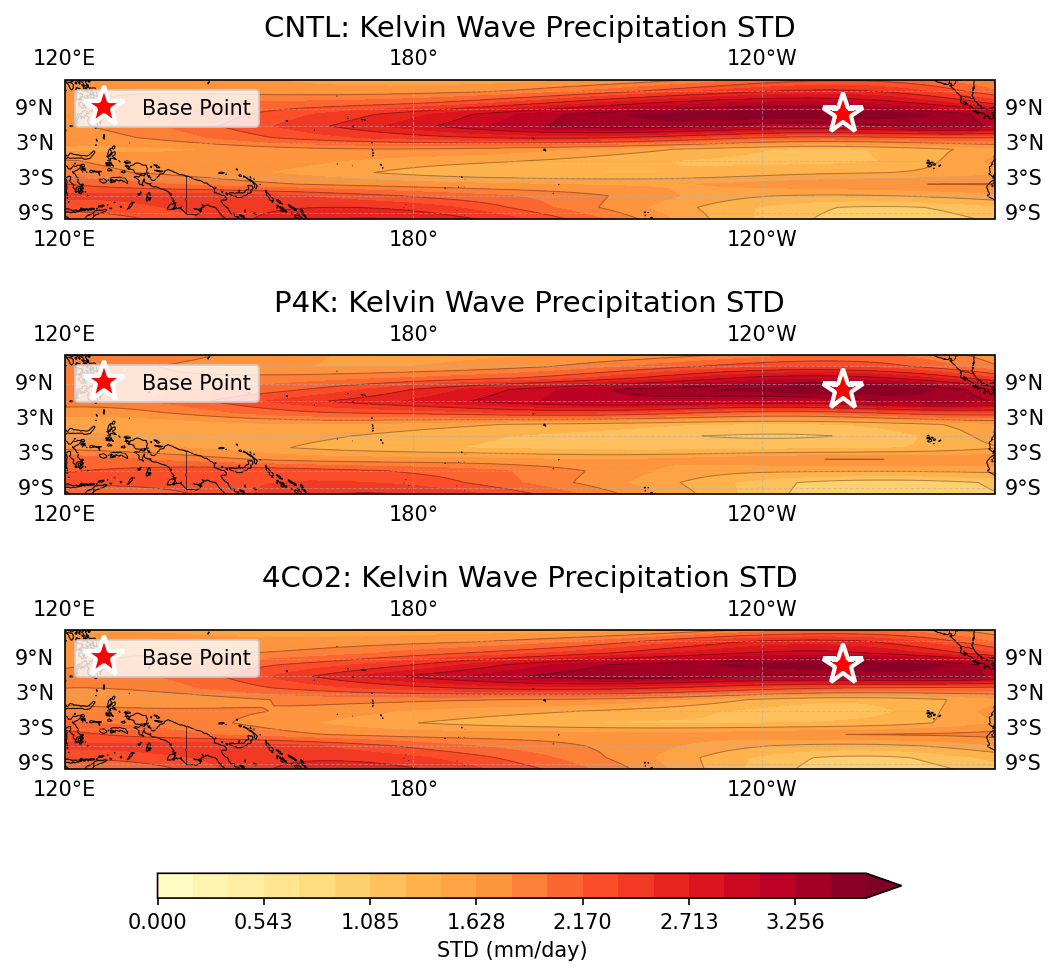


✅ Base point visualization completed


In [16]:
# Step 6b: 绘制降水STD分布并标记base point
print("="*70)
print("🎨 Plotting precipitation STD distribution with base point")
print("="*70)

# 创建子图
fig = plt.figure(figsize=(8, 9), dpi=150)
ax_list = []
for i, exp in enumerate(['CNTL', 'P4K', '4CO2'], 1):
    ax = fig.add_subplot(3, 1, i, projection=ccrs.PlateCarree(central_longitude=180))
    ax_list.append(ax)
    # 获取该实验的STD数据
    pr_std = pr_std_data[exp]
    
    # 选择太平洋区域
    pr_std_pacific = pr_std.sel(lon=pacific_lon, lat=pacific_lat)
    
    # 绘制填色图
    levels = np.linspace(0, pr_std_pacific.max().values, 21)
    cs = ax.contourf(pr_std_pacific.lon, pr_std_pacific.lat, pr_std_pacific,
                     levels=levels, cmap='YlOrRd', extend='max',
                     transform=ccrs.PlateCarree())
    
    # 添加等值线
    cs2 = ax.contour(pr_std_pacific.lon, pr_std_pacific.lat, pr_std_pacific,
                     levels=levels[::2], colors='black', linewidths=0.5, alpha=0.3,
                     transform=ccrs.PlateCarree())
    
    # 标记base point（使用共同的base point）
    ax.plot(base_lon, base_lat, 'r*', markersize=20, 
            markeredgecolor='white', markeredgewidth=2,
            transform=ccrs.PlateCarree(), label='Base Point', zorder=10)
    

    
    # 显示该实验在base point的STD值
    std_val = base_point_info[f'{exp}_std']

    # 添加海岸线和网格
    ax.coastlines(resolution='50m', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    
    # 设置标题
    ax.set_title(f'{exp}: Kelvin Wave Precipitation STD', 
                 fontsize=14,)
    
    ax.legend(loc='best', fontsize=10)
    # 添加colorbar
    
cbar = plt.colorbar(cs, ax=ax_list, orientation='horizontal', 
                pad=0.1, aspect=30, shrink=0.8)
cbar.set_label('STD (mm/day)', fontsize=10,)


# 保存图形
save_path = os.path.join(fig_save_dir, 'pr_std_with_basepoint.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Plot saved: {save_path}")

plt.show()
plt.close()

print("\n" + "="*70)
print("✅ Base point visualization completed")
print("="*70)

🎨 Creating comparison plot of all three experiments


/tmp/ipykernel_1289987/3535300234.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right', fontsize=12, framealpha=0.9)



✅ Comparison plot saved: ./figures/Cal_cckws_3d_fields/pr_std_ensemble_mean_basepoint.png


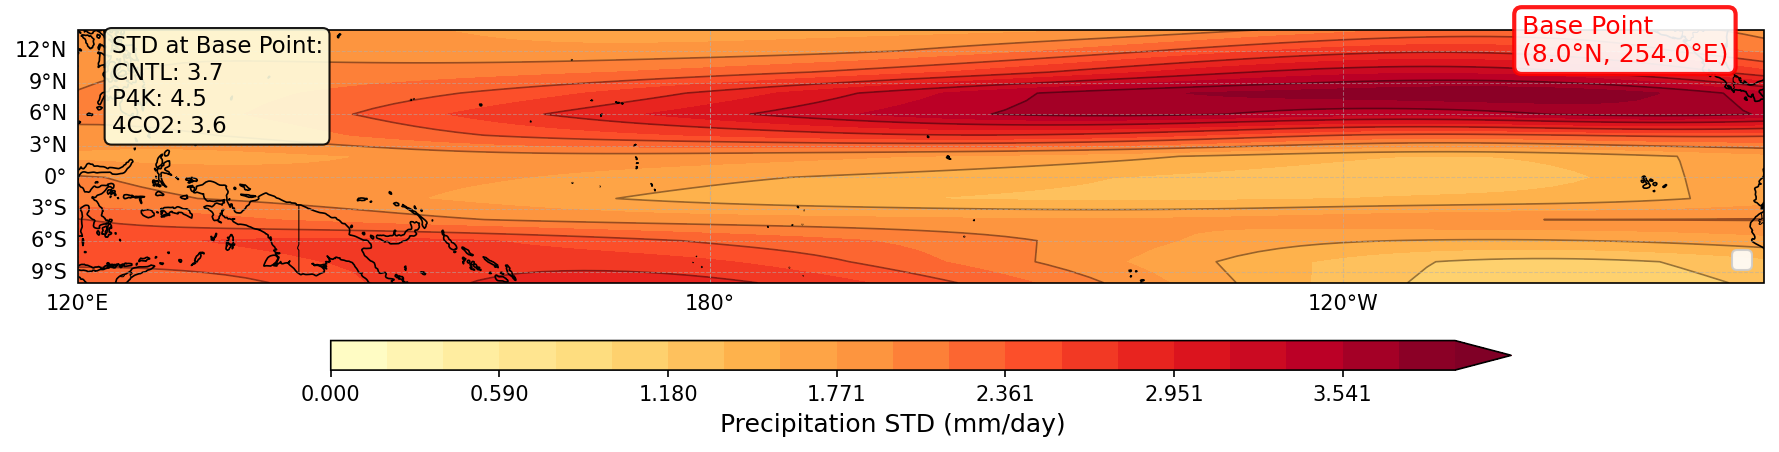


✅ Ensemble mean base point visualization completed
📍 Common base point: (8.00°N, 254.00°E)


In [17]:
# Step 6c: 绘制三实验对比的降水STD分布
print("="*70)
print("🎨 Creating comparison plot of all three experiments")
print("="*70)

# 创建单个图，显示三个实验的平均STD
fig, ax = plt.subplots(figsize=(12, 8), dpi=150, 
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

# 计算三个实验的平均STD（用于显示）
pr_std_pacific_list = []
for exp in ['CNTL', 'P4K', '4CO2']:
    pr_std_pacific = pr_std_data[exp].sel(lon=pacific_lon, lat=pacific_lat)
    pr_std_pacific_list.append(pr_std_pacific)

pr_std_mean = sum(pr_std_pacific_list) / 3.0

# 绘制平均STD
levels = np.linspace(0, pr_std_mean.max().values, 21)
cs = ax.contourf(pr_std_mean.lon, pr_std_mean.lat, pr_std_mean,
                 levels=levels, cmap='YlOrRd', extend='max',
                 transform=ccrs.PlateCarree())

# 添加等值线
cs2 = ax.contour(pr_std_mean.lon, pr_std_mean.lat, pr_std_mean,
                 levels=levels[::2], colors='black', linewidths=0.8, alpha=0.4,
                 transform=ccrs.PlateCarree())

# 添加文字标注
ax.text(base_lon + 3, base_lat + 3, 
        f'Base Point\n({base_lat:.1f}°N, {base_lon:.1f}°E)',
        fontsize=12, color='red', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='red', linewidth=2),
        transform=ccrs.PlateCarree(), ha='left')

# 显示三个实验在base point的STD值
text_str = "STD at Base Point:\n"
for exp in ['CNTL', 'P4K', '4CO2']:
    std_val = base_point_info[f'{exp}_std']
    text_str += f"{exp}: {std_val:.2}\n"

ax.text(0.02, 0.98, text_str.strip(),
        transform=ax.transAxes, fontsize=11, 
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='black'))

# 添加海岸线和网格
ax.coastlines(resolution='50m', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# 设置标题
# 添加colorbar
cbar = plt.colorbar(cs, ax=ax, orientation='horizontal', 
                   pad=0.05, aspect=40, shrink=0.7)
cbar.set_label('Precipitation STD (mm/day)', fontsize=12, )
cbar.ax.tick_params(labelsize=10)

ax.legend(loc='lower right', fontsize=12, framealpha=0.9)

plt.tight_layout()

# 保存图形
save_path = os.path.join(fig_save_dir, 'pr_std_ensemble_mean_basepoint.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Comparison plot saved: {save_path}")

plt.show()
plt.close()

print("\n" + "="*70)
print("✅ Ensemble mean base point visualization completed")
print(f"📍 Common base point: ({base_lat:.2f}°N, {base_lon:.2f}°E)")
print("="*70)

In [18]:
# # 关闭 SLURM 集群（完成所有计算后运行）
# print("="*70)
# print("🛑 Closing SLURM Cluster")
# print("="*70)

# if USE_SLURM and 'client' in globals() and client is not None:
#     print("📊 Final cluster statistics:")
#     print(f"   Dashboard: {client.dashboard_link}")
#     print(f"   Total workers used: {len(client.scheduler_info()['workers'])}")
    
#     print("\n🔄 Closing client and cluster...")
#     client.close()
#     cluster.close()
#     print("✅ SLURM cluster closed successfully")
# else:
#     print("⚠️  No active SLURM cluster to close")

# print("="*70)

🛑 Closing SLURM Cluster
📊 Final cluster statistics:
   Dashboard: http://10.128.10.135:8788/status
   Total workers used: 0

🔄 Closing client and cluster...
✅ SLURM cluster closed successfully
